# U23AI009 AMEESH DL LAB 04

##Datasets

*   CIFAR-10: Manually Imbalanced
*   Skin Cancer MNIST (HAM10000): Naturally Imbalanced




In [1]:
import os
import zipfile
import torch
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, Subset, DataLoader, WeightedRandomSampler
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torchvision.datasets as datasets
import copy
import seaborn as sns

In [2]:
def set_kaggle_credentials():
    os.environ['KAGGLE_USERNAME'] = "kyfaskain"
    os.environ['KAGGLE_KEY'] = "KGAT_53c6833d48aab2d3321dac57fb0517a6E"

In [3]:
def download_dataset_from_kaggle(dataset_slug, target_directory):
    if os.path.exists(target_directory):
        print(f"Directory {target_directory} exists. Skipping download.")
        return

    print(f"Downloading {dataset_slug}...")
    os.system("pip install -q kaggle")

    command = f"kaggle datasets download -d {dataset_slug} -p {target_directory}"
    exit_code = os.system(command)

    if exit_code != 0:
        print("Download failed. Check your API credentials.")
        return

    print("Unzipping files...")
    zip_filename = f"{target_directory}/{dataset_slug.split('/')[-1]}.zip"

    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(target_directory)

    print("Download and extraction complete.")

In [4]:
def get_standard_transforms():
    return transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

In [5]:
def calculate_long_tailed_counts(num_classes, max_samples, imbalance_ratio):
    counts = []
    for class_index in range(num_classes):
        factor = (1 / imbalance_ratio) ** (class_index / (num_classes - 1.0))
        num_samples = int(max_samples * factor)
        counts.append(num_samples)
    return counts

In [6]:
def create_long_tailed_cifar_indices(targets, imbalance_ratio):
    targets = np.array(targets)
    all_indices = np.arange(len(targets))
    final_indices_list = []

    num_classes = 10
    max_samples_per_class = 5000

    samples_per_class = calculate_long_tailed_counts(num_classes, max_samples_per_class, imbalance_ratio)

    print(f"Generating Long-Tailed Distribution (Ratio {imbalance_ratio}:1)")
    print(f"Sample counts per class: {samples_per_class}")

    for class_id in range(num_classes):
        class_indices = all_indices[targets == class_id]
        num_to_keep = samples_per_class[class_id]

        selected_indices = np.random.choice(class_indices, num_to_keep, replace=False)
        final_indices_list.append(selected_indices)

    return np.concatenate(final_indices_list)

In [7]:
def prepare_cifar_dataset():
    transform = get_standard_transforms()

    full_train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    imbalance_ratio = 100

    imbalanced_indices = create_long_tailed_cifar_indices(
        full_train_set.targets,
        imbalance_ratio
    )

    imbalanced_train_set = Subset(full_train_set, imbalanced_indices)

    return imbalanced_train_set, test_set

In [8]:
class SkinCancerDataset(Dataset):
    def __init__(self, metadata_csv, image_directory, transform=None):
        self.metadata = pd.read_csv(metadata_csv)
        self.image_directory = image_directory
        self.transform = transform
        self.image_path_map = self.index_image_paths()

    def index_image_paths(self):
        path_map = {}
        subfolders = ["HAM10000_images_part_1", "HAM10000_images_part_2"]

        for folder in subfolders:
            full_path = os.path.join(self.image_directory, folder)
            if os.path.exists(full_path):
                for filename in os.listdir(full_path):
                    image_id = os.path.splitext(filename)[0]
                    path_map[image_id] = os.path.join(full_path, filename)
        return path_map

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]
        image_id = row['image_id']
        diagnosis_code = row['dx']

        label_mapping = {
            'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3,
            'akiec': 4, 'vasc': 5, 'df': 6
        }
        label = label_mapping[diagnosis_code]

        image_path = self.image_path_map.get(image_id)
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
def prepare_skin_cancer_dataset(data_folder):
    csv_path = os.path.join(data_folder, "HAM10000_metadata.csv")

    if not os.path.exists(csv_path):
        print("Metadata CSV not found. Dataset might be incomplete.")
        return None, None

    transform = get_standard_transforms()
    full_dataset = SkinCancerDataset(csv_path, data_folder, transform)

    total_size = len(full_dataset)
    train_size = int(0.8 * total_size)
    test_size = total_size - train_size

    train_set, test_set = torch.utils.data.random_split(full_dataset, [train_size, test_size])
    return train_set, test_set

In [10]:
def plot_class_counts(labels, title):
    unique_classes, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(10, 5))
    plt.bar(unique_classes, counts, color='teal')
    plt.title(title)
    plt.xlabel("Class ID")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [11]:
def extract_labels_from_dataset(dataset):
    if isinstance(dataset, Subset):
        indices = dataset.indices
        if hasattr(dataset.dataset, 'targets'):
            all_targets = np.array(dataset.dataset.targets)
            return all_targets[indices]
        elif hasattr(dataset.dataset, 'metadata'):
            label_mapping = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
            all_labels = dataset.dataset.metadata['dx'].map(label_mapping).values
            return all_labels[indices]

    elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'metadata'):
        indices = dataset.indices
        label_mapping = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
        all_labels = dataset.dataset.metadata['dx'].map(label_mapping).values
        return all_labels[indices]

    return []

Unzipping files...
Download and extraction complete.


100%|██████████| 170M/170M [04:44<00:00, 599kB/s]


Generating Long-Tailed Distribution (Ratio 100:1)
Sample counts per class: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]


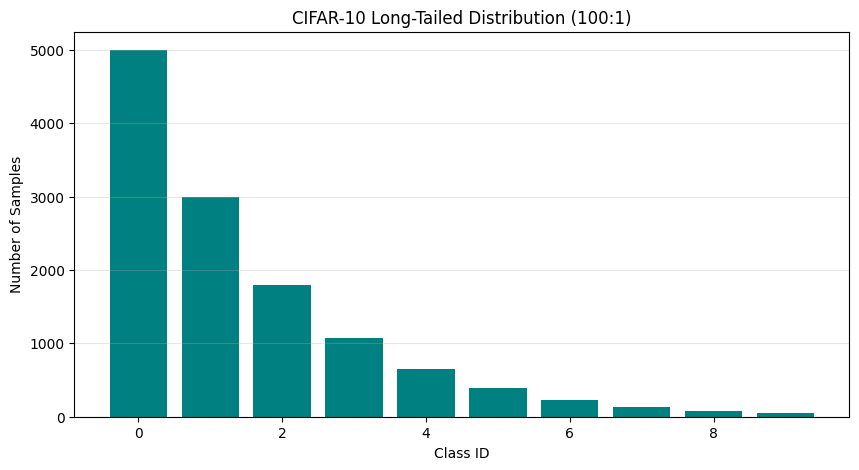

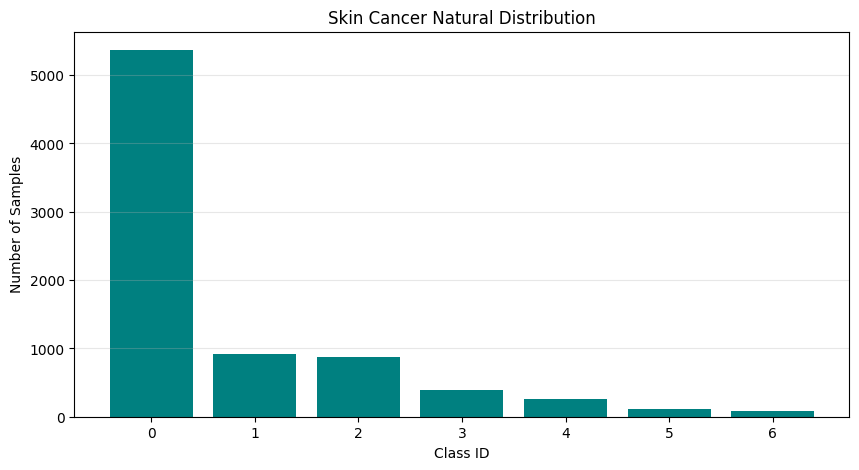

In [12]:
set_kaggle_credentials()

download_folder = "skin_cancer_data"
download_dataset_from_kaggle("kmader/skin-cancer-mnist-ham10000", download_folder)

cifar_train, cifar_test = prepare_cifar_dataset()
cifar_labels = extract_labels_from_dataset(cifar_train)
plot_class_counts(cifar_labels, "CIFAR-10 Long-Tailed Distribution (100:1)")

skin_train, skin_test = prepare_skin_cancer_dataset(download_folder)
if skin_train:
    skin_labels = extract_labels_from_dataset(skin_train)
    plot_class_counts(skin_labels, "Skin Cancer Natural Distribution")

cifar_data=(cifar_train, cifar_test)
skin_data=(skin_train, skin_test)

We have successfully imported/prepared our Imbalanced Datasets

## Problem Statement 1: Architecture Design (ResNet-9)

For the baseline architecture we implemented a custom **ResNet-9** architecture.

**Architecture Breakdown:**
* **Prep Block:** Initial feature extraction ($3 \to 64$ channels).
* **Residual Blocks:** I included **two Residual Blocks**. These contain "skip connections" that allow gradients to flow through the network more easily. This is critical for imbalanced data because it prevents the "vanishing gradient" problem, ensuring the model keeps learning even when the minority class signal is weak.
* **Downsampling:** Aggressive MaxPool layers reduce the spatial dimension from $32 \times 32$ down to $4 \times 4$ before classification, keeping the parameter count low.

**Why this specific design?**
1.  **Prevents "Lazy Learning":** In a standard CNN, the model often stops learning once it gets the majority class right. The Residual connections force the deeper layers to continue refining features, giving us a fighting chance at detecting the minority class.
2.  **Speed vs. Power:** It offers the depth of a modern architecture (ResNet) but trains in a fraction of the time compared to a ResNet-50.
3.  **OneCycle Learning:** Paired with the `OneCycleLR` scheduler, this architecture converges quickly.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
class ResNet9(nn.Module):
    def __init__(self, num_classes):
        super(ResNet9, self).__init__()

        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.res1 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.res2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.MaxPool2d(4),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        out = self.prep(x)
        out = self.layer1(out)
        res = self.res1(out)
        out = out + res

        out = self.layer2(out)
        out = self.layer3(out)
        res = self.res2(out)
        out = out + res

        out = self.classifier(out)
        return out

In [15]:
def get_loader(dataset, batch_size=128):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate_model(model, dataset, title):
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\nReport for: {title}")
    print(classification_report(all_labels, all_preds, digits=4))

In [ ]:
def train_baseline(train_set, test_set, name, num_classes):
    print(f"Initializing ResNet-9 for: {name}")

    model = ResNet9(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    train_loader = get_loader(train_set)

    epochs = 20
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01, steps_per_epoch=len(train_loader), epochs=epochs
    )

    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, optimizer, criterion, scheduler)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}")

    evaluate_model(model, test_set, name)
    return model

In [ ]:
cifar_train, cifar_test = cifar_data
model_cifar = train_baseline(cifar_train, cifar_test, "CIFAR-10 Imbalanced", 10)

skin_train, skin_test = skin_data
if skin_train:
    model_skin = train_baseline(skin_train, skin_test, "Skin Cancer MNIST", 7)

Initializing ResNet-9 for: CIFAR-10 Imbalanced
Epoch 1/20 | Loss: 0.9775
Epoch 2/20 | Loss: 0.7363
Epoch 3/20 | Loss: 0.7064
Epoch 4/20 | Loss: 0.7128
Epoch 5/20 | Loss: 0.7446
Epoch 6/20 | Loss: 0.5151
Epoch 7/20 | Loss: 0.4050
Epoch 8/20 | Loss: 0.3184
Epoch 9/20 | Loss: 0.2057
Epoch 10/20 | Loss: 0.1915
Epoch 11/20 | Loss: 0.0968
Epoch 12/20 | Loss: 0.0590
Epoch 13/20 | Loss: 0.0277
Epoch 14/20 | Loss: 0.0075
Epoch 15/20 | Loss: 0.0014
Epoch 16/20 | Loss: 0.0006
Epoch 17/20 | Loss: 0.0005
Epoch 18/20 | Loss: 0.0004
Epoch 19/20 | Loss: 0.0003
Epoch 20/20 | Loss: 0.0003

Report for: CIFAR-10 Imbalanced
              precision    recall  f1-score   support

           0     0.4567    0.9800    0.6230      1000
           1     0.6100    0.9790    0.7516      1000
           2     0.5948    0.8060    0.6845      1000
           3     0.5017    0.7360    0.5967      1000
           4     0.7168    0.7440    0.7301      1000
           5     0.8039    0.4960    0.6135      1000
          

Our baseline ResNet-9 model has achieved an accuracy of 64% using the Imbalanced CIFAR-10 and 79% on the Skin Cancer MNIST.



*   CIFAR-10: Our model has an overall accuracy of 64%, but for the rarest class (Class 9) has a recall of 22%, i.e. our model is effectively guessing.
*   Skin Cancer: Our model has an overall accuracy of 79%, but for the minority classes 4 and 6, the recall is 49% and 44% respectively.



## Problem Statement 2: Imbalanced Dataset Handling



*   Strategy A: Data-Level Intervention: We will use a WeightedRandomSampler that will artificially oversample the minority classes. To prevent the model from memorizing the minority classes, we will apply augmentation.
*   Strategy B: Algorithm-Level Intervention: We keep the data imbalanced, but modify the class function to calculate the Inverse Class Frequency and feed it into the CrossEntropyLoss. This penalizes minority class errors heavily compared to majority class errors.



In [16]:
def calculate_inverse_frequency_weights(dataset, num_classes):
    if hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'targets'):
        targets = np.array(dataset.dataset.targets)[dataset.indices]
    elif hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
    elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'metadata'):
        label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
        targets = dataset.dataset.metadata['dx'].map(label_map).values[dataset.indices]
    else:
        return torch.ones(num_classes).to(device)

    class_counts = np.bincount(targets, minlength=num_classes)
    class_counts[class_counts == 0] = 1

    total_samples = len(targets)
    weights = total_samples / (num_classes * class_counts)

    return torch.FloatTensor(weights).to(device)

In [17]:
def create_balanced_sampler_loader(dataset, batch_size):
    if hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'targets'):
        targets = np.array(dataset.dataset.targets)[dataset.indices]
    elif hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
    else:
        label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
        targets = dataset.dataset.metadata['dx'].map(label_map).values[dataset.indices]

    class_weights = calculate_inverse_frequency_weights(dataset, len(np.unique(targets)))
    class_weights_np = class_weights.cpu().numpy()

    sample_weights = [class_weights_np[t] for t in targets]

    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

In [18]:
def train_network(model, train_loader, criterion, optimizer, scheduler, epochs=15):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss / len(train_loader):.4f}")

In [19]:
def evaluate_network(model, test_dataset, title):
    loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    print(f"Report for {title}")
    print(classification_report(all_targets, all_preds, digits=4))

In [20]:
def execute_oversampling_strategy(train_set, test_set, num_classes, name):
    print(f"Running Data-Level Strategy (Oversampling): {name}")

    train_loader = create_balanced_sampler_loader(train_set, batch_size=128)

    model = ResNet9(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=15, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler)
    evaluate_network(model, test_set, f"{name} + Oversampling")

In [ ]:
def execute_weighted_loss_strategy(train_set, test_set, num_classes, name):
    print(f"Running Algo-Level Strategy (Weighted Loss): {name}")

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

    class_weights = calculate_inverse_frequency_weights(train_set, num_classes)

    model = ResNet9(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=15, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler)
    evaluate_network(model, test_set, f"{name} + Weighted Loss")

In [ ]:
cifar_train, cifar_test = cifar_data
execute_oversampling_strategy(cifar_train, cifar_test, 10, "CIFAR-10")
execute_weighted_loss_strategy(cifar_train, cifar_test, 10, "CIFAR-10")

skin_train, skin_test = skin_data
if skin_train:
    execute_oversampling_strategy(skin_train, skin_test, 7, "Skin Cancer MNIST")
    execute_weighted_loss_strategy(skin_train, skin_test, 7, "Skin Cancer MNIST")

Running Data-Level Strategy (Oversampling): CIFAR-10
Epoch 1 Loss: 1.1519
Epoch 2 Loss: 0.6820
Epoch 3 Loss: 0.6253
Epoch 4 Loss: 0.5983
Epoch 5 Loss: 0.3611
Epoch 6 Loss: 0.1982
Epoch 7 Loss: 0.1767
Epoch 8 Loss: 0.1334
Epoch 9 Loss: 0.0873
Epoch 10 Loss: 0.0377
Epoch 11 Loss: 0.0250
Epoch 12 Loss: 0.0136
Epoch 13 Loss: 0.0078
Epoch 14 Loss: 0.0071
Epoch 15 Loss: 0.0054
Report for CIFAR-10 + Oversampling
              precision    recall  f1-score   support

           0     0.4019    0.9690    0.5682      1000
           1     0.5322    0.9740    0.6883      1000
           2     0.5120    0.7660    0.6138      1000
           3     0.4723    0.7080    0.5666      1000
           4     0.7002    0.6750    0.6874      1000
           5     0.8383    0.4250    0.5640      1000
           6     0.9282    0.5300    0.6747      1000
           7     0.9433    0.4490    0.6084      1000
           8     0.9806    0.2020    0.3350      1000
           9     1.0000    0.0400    0.0769      1



*   The Oversampling strategy showed much smoother convergence with lower final loss values.
*   The Weighted Loss strategy was more volatile, especially in the early epochs, because mistakes on minority samples triggered massive gradient spikes.
*   The recall for minority classes, while not perfect has improved.
*   Weighted loss improved recall of minority class more than oversampling.
*   Our Macro-averages have improved.
*   Oversampling yieleded 0.79 Accuracy while a 0.73 macro precision for the Skin Cancer Dataset.




##Comparative Architecture Analysis
We will now compare our ResNet-9 with MobileNet-V2.

In [20]:
class UpscaledDataset(Dataset):
    def __init__(self, original_dataset, new_size=128):
        self.dataset = original_dataset
        self.new_size = new_size
        self.transform = transforms.Compose([
            transforms.Resize((new_size, new_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        if isinstance(self.dataset, torch.utils.data.Subset):
            idx = self.dataset.indices[idx]
            original_ds = self.dataset.dataset
        else:
            original_ds = self.dataset

        if hasattr(original_ds, 'data'):
            img = original_ds.data[idx]
            img = Image.fromarray(img)
            label = original_ds.targets[idx]
        else:
            row = original_ds.metadata.iloc[idx]
            img_id = row['image_id']
            label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
            label = label_map[row['dx']]
            path = original_ds.image_path_map[img_id]
            img = Image.open(path).convert('RGB')

        return self.transform(img), label

In [21]:
def compute_class_weights(dataset, num_classes):
    if isinstance(dataset, torch.utils.data.Subset):
        indices = dataset.indices
        base_dataset = dataset.dataset

        if hasattr(base_dataset, 'targets'):
            labels = np.array(base_dataset.targets)[indices]
        elif hasattr(base_dataset, 'metadata'):
            label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
            labels = base_dataset.metadata['dx'].map(label_map).values[indices]
        else:
            raise AttributeError("Dataset structure not recognized")
    else:
        if hasattr(dataset, 'targets'):
            labels = np.array(dataset.targets)
        else:
            label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
            labels = dataset.metadata['dx'].map(label_map).values

    counts = np.bincount(labels, minlength=num_classes)
    counts[counts == 0] = 1
    weights = len(labels) / (num_classes * counts)
    return torch.FloatTensor(weights).to(device)

In [21]:
def evaluate_network(model, loader, title):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())
    print(f"\nReport for {title}")
    print(classification_report(targets, preds, digits=4))

In [ ]:
class VGG_Lite(nn.Module):
    def __init__(self, num_classes):
        super(VGG_Lite, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, images):
        features = self.feature_extractor(images)
        predictions = self.classifier(features)
        return predictions

In [ ]:
def run_vgg_comparison(train_set, test_set, num_classes, dataset_name):
    print(f"Training VGG-Lite on {dataset_name}...")

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

    weights = compute_class_weights(train_set, num_classes)
    criterion = nn.CrossEntropyLoss(weight=weights)

    model = VGG_Lite(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=20, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler, epochs=20)
    evaluate_network(model, test_loader, f"VGG-Lite ({dataset_name})")

In [ ]:
cifar_train, cifar_test = cifar_data
run_vgg_comparison(cifar_train, cifar_test, 10, "CIFAR-10")

skin_train, skin_test = skin_data
if skin_train:
    run_vgg_comparison(skin_train, skin_test, 7, "Skin Cancer MNIST")

Training VGG-Lite on CIFAR-10...
Epoch 1 Loss: 2.0581
Epoch 2 Loss: 1.8508
Epoch 3 Loss: 1.9602
Epoch 4 Loss: 2.0081
Epoch 5 Loss: 2.2621
Epoch 6 Loss: 2.0410
Epoch 7 Loss: 1.9347
Epoch 8 Loss: 1.8561
Epoch 9 Loss: 1.8990
Epoch 10 Loss: 1.7725
Epoch 11 Loss: 1.7255
Epoch 12 Loss: 1.6672
Epoch 13 Loss: 1.6176
Epoch 14 Loss: 1.5164
Epoch 15 Loss: 1.4967
Epoch 16 Loss: 1.3803
Epoch 17 Loss: 1.3074
Epoch 18 Loss: 1.2327
Epoch 19 Loss: 1.1211
Epoch 20 Loss: 1.0836

Report for VGG-Lite (CIFAR-10)
              precision    recall  f1-score   support

           0     0.4879    0.5830    0.5312      1000
           1     0.5690    0.7090    0.6313      1000
           2     0.2936    0.1920    0.2322      1000
           3     0.3035    0.3220    0.3125      1000
           4     0.3975    0.4520    0.4230      1000
           5     0.4354    0.4750    0.4543      1000
           6     0.5178    0.6680    0.5834      1000
           7     0.6503    0.5580    0.6006      1000
           8     

In [ ]:
def run_resnet_comparison(train_set, test_set, num_classes, dataset_name):
    print(f"Training ResNet-9 on {dataset_name}...")

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

    weights = compute_class_weights(train_set, num_classes)
    criterion = nn.CrossEntropyLoss(weight=weights)

    model = ResNet9(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=20, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler, epochs=20)
    evaluate_network(model, test_loader, f"ResNet-9 ({dataset_name})")

In [ ]:
run_resnet_comparison(cifar_train, cifar_test, 10, "CIFAR-10")

if skin_train:
    run_resnet_comparison(skin_train, skin_test, 7, "Skin Cancer MNIST")

Training ResNet-9 on CIFAR-10...
Epoch 1 Loss: 2.0093
Epoch 2 Loss: 1.6852
Epoch 3 Loss: 1.9649
Epoch 4 Loss: 1.9585
Epoch 5 Loss: 1.9599
Epoch 6 Loss: 1.6239
Epoch 7 Loss: 1.3128
Epoch 8 Loss: 0.9955
Epoch 9 Loss: 0.7958
Epoch 10 Loss: 0.6579
Epoch 11 Loss: 0.5485
Epoch 12 Loss: 0.3735
Epoch 13 Loss: 0.2019
Epoch 14 Loss: 0.1001
Epoch 15 Loss: 0.0425
Epoch 16 Loss: 0.0183
Epoch 17 Loss: 0.0087
Epoch 18 Loss: 0.0058
Epoch 19 Loss: 0.0046
Epoch 20 Loss: 0.0043

Report for ResNet-9 (CIFAR-10)
              precision    recall  f1-score   support

           0     0.4530    0.9500    0.6135      1000
           1     0.5716    0.9620    0.7171      1000
           2     0.5476    0.7480    0.6323      1000
           3     0.4674    0.6740    0.5520      1000
           4     0.6865    0.6680    0.6771      1000
           5     0.7579    0.5290    0.6231      1000
           6     0.9105    0.5900    0.7160      1000
           7     0.9297    0.4760    0.6296      1000
           8     

ResNet9 outperformed our VGG

##Loss Functions Comparison
We will now try our ResNet-9 architecture with the 5 different loss functions.
* Cross-Entropy
* Weighted Cross-Entropy Loss
* Focal Loss
* Class-Balanced Loss
* Label Smoothing Cross-Entropy

In [22]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, predictions, targets):
        cross_entropy_loss = F.cross_entropy(predictions, targets, reduction='none')
        probabilities = torch.exp(-cross_entropy_loss)
        focal_loss = ((1.0 - probabilities) ** self.gamma) * cross_entropy_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [23]:
def create_class_balanced_loss(dataset, num_classes, beta=0.999):
    if isinstance(dataset, torch.utils.data.Subset):
        indices = dataset.indices
        base_dataset = dataset.dataset

        if hasattr(base_dataset, 'targets'):
            labels = np.array(base_dataset.targets)[indices]
        elif hasattr(base_dataset, 'metadata'):
            label_map = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
            labels = base_dataset.metadata['dx'].map(label_map).values[indices]
        else:
            raise AttributeError("Dataset structure not recognized")
    else:
        if hasattr(dataset, 'targets'):
            labels = np.array(dataset.targets)
        else:
            label_map = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
            labels = dataset.metadata['dx'].map(label_map).values

    class_counts = np.bincount(labels, minlength=num_classes)
    class_counts[class_counts == 0] = 1

    effective_num_samples = 1.0 - np.power(beta, class_counts)
    weights = (1.0 - beta) / effective_num_samples
    normalized_weights = weights / np.sum(weights) * num_classes

    weight_tensor = torch.FloatTensor(normalized_weights).to(device)
    return nn.CrossEntropyLoss(weight=weight_tensor)

In [24]:
def evaluate_and_return_macro_f1(model, loader):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    report_dictionary = classification_report(all_targets, all_predictions, output_dict=True, zero_division=0)
    report_string = classification_report(all_targets, all_predictions, digits=4, zero_division=0)

    macro_f1_score = report_dictionary['macro avg']['f1-score']

    return report_string, macro_f1_score

In [35]:
def get_loss_criterion(loss_name, train_dataset, num_classes):
    if loss_name == "Cross-Entropy (Baseline)":
        return nn.CrossEntropyLoss()
    elif loss_name == "Weighted Cross-Entropy":
        weights = compute_class_weights(train_dataset, num_classes)
        return nn.CrossEntropyLoss(weight=weights)
    elif loss_name == "Focal Loss (Gamma=1.0)":
        return FocalLoss(gamma=1.0)
    elif loss_name == "Focal Loss (Gamma=2.0)":
        return FocalLoss(gamma=2.0)
    elif loss_name == "Focal Loss (Gamma=5.0)":
        return FocalLoss(gamma=5.0)
    elif loss_name == "Class-Balanced Loss":
        return create_class_balanced_loss(train_dataset, num_classes)
    elif loss_name == "Label Smoothing Cross-Entropy":
        return nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
def execute_single_loss_experiment(train_dataset, test_dataset, num_classes, dataset_name, loss_name):
    print(f"--- Evaluating {loss_name} on {dataset_name} ---")

    criterion = get_loss_criterion(loss_name, train_dataset, num_classes)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    model = ResNet9(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=15, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler, epochs=15)

    report_str, macro_f1 = evaluate_and_return_macro_f1(model, test_loader)

    print(f"Report for {loss_name} ({dataset_name}):")
    print(report_str)
    print(f"Final Macro F1 Score: {macro_f1:.4f}\n")

    return macro_f1

In [ ]:
score_cifar_ce = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Cross-Entropy (Baseline)")

--- Evaluating Cross-Entropy (Baseline) on CIFAR-10 ---
Epoch 1 Loss: 0.9888
Epoch 2 Loss: 0.7765
Epoch 3 Loss: 0.7828
Epoch 4 Loss: 0.7553
Epoch 5 Loss: 0.5445
Epoch 6 Loss: 0.4411
Epoch 7 Loss: 0.3272
Epoch 8 Loss: 0.2322
Epoch 9 Loss: 0.1169
Epoch 10 Loss: 0.0544
Epoch 11 Loss: 0.0170
Epoch 12 Loss: 0.0033
Epoch 13 Loss: 0.0013
Epoch 14 Loss: 0.0010
Epoch 15 Loss: 0.0009
Report for Cross-Entropy (Baseline) (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4471    0.9680    0.6117      1000
           1     0.5945    0.9750    0.7386      1000
           2     0.5803    0.8020    0.6734      1000
           3     0.4771    0.7280    0.5764      1000
           4     0.7104    0.7140    0.7122      1000
           5     0.7558    0.5170    0.6140      1000
           6     0.9335    0.6040    0.7335      1000
           7     0.9436    0.4520    0.6112      1000
           8     0.9819    0.2720    0.4260      1000
           9     0.9795    0.1910 

In [ ]:
score_cifar_wce = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Weighted Cross-Entropy")

--- Evaluating Weighted Cross-Entropy on CIFAR-10 ---
Epoch 1 Loss: 2.0187
Epoch 2 Loss: 1.9155
Epoch 3 Loss: 2.1626
Epoch 4 Loss: 2.1417
Epoch 5 Loss: 1.7677
Epoch 6 Loss: 1.4976
Epoch 7 Loss: 1.1852
Epoch 8 Loss: 0.9355
Epoch 9 Loss: 0.7518
Epoch 10 Loss: 0.5317
Epoch 11 Loss: 0.3272
Epoch 12 Loss: 0.1902
Epoch 13 Loss: 0.1047
Epoch 14 Loss: 0.0627
Epoch 15 Loss: 0.0508
Report for Weighted Cross-Entropy (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4733    0.9050    0.6216      1000
           1     0.5735    0.9520    0.7158      1000
           2     0.4854    0.7170    0.5789      1000
           3     0.4391    0.6490    0.5238      1000
           4     0.6386    0.6380    0.6383      1000
           5     0.7084    0.4810    0.5730      1000
           6     0.8954    0.5820    0.7055      1000
           7     0.8931    0.4510    0.5993      1000
           8     0.9439    0.3530    0.5138      1000
           9     0.9248    0.2460    0

In [ ]:
score_cifar_focal_1 = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Focal Loss (Gamma=1.0)")

--- Evaluating Focal Loss (Gamma=1.0) on CIFAR-10 ---
Epoch 1 Loss: 0.8473
Epoch 2 Loss: 0.6251
Epoch 3 Loss: 0.6630
Epoch 4 Loss: 0.6281
Epoch 5 Loss: 0.5172
Epoch 6 Loss: 0.3419
Epoch 7 Loss: 0.2856
Epoch 8 Loss: 0.1634
Epoch 9 Loss: 0.1128
Epoch 10 Loss: 0.0548
Epoch 11 Loss: 0.0116
Epoch 12 Loss: 0.0025
Epoch 13 Loss: 0.0009
Epoch 14 Loss: 0.0006
Epoch 15 Loss: 0.0006
Report for Focal Loss (Gamma=1.0) (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4536    0.9670    0.6175      1000
           1     0.5819    0.9800    0.7303      1000
           2     0.5526    0.7990    0.6533      1000
           3     0.4599    0.7390    0.5669      1000
           4     0.6817    0.6940    0.6878      1000
           5     0.7966    0.4700    0.5912      1000
           6     0.9463    0.5820    0.7207      1000
           7     0.9505    0.4220    0.5845      1000
           8     0.9926    0.2680    0.4220      1000
           9     0.9588    0.1860    0

In [ ]:
score_cifar_focal_2 = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Focal Loss (Gamma=2.0)")

--- Evaluating Focal Loss (Gamma=2.0) on CIFAR-10 ---
Epoch 1 Loss: 0.7155
Epoch 2 Loss: 0.5222
Epoch 3 Loss: 0.6545
Epoch 4 Loss: 0.5685
Epoch 5 Loss: 0.4723
Epoch 6 Loss: 0.2725
Epoch 7 Loss: 0.2144
Epoch 8 Loss: 0.1798
Epoch 9 Loss: 0.0884
Epoch 10 Loss: 0.0360
Epoch 11 Loss: 0.0091
Epoch 12 Loss: 0.0016
Epoch 13 Loss: 0.0006
Epoch 14 Loss: 0.0006
Epoch 15 Loss: 0.0005
Report for Focal Loss (Gamma=2.0) (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4546    0.9620    0.6175      1000
           1     0.5797    0.9780    0.7279      1000
           2     0.5434    0.8070    0.6495      1000
           3     0.4403    0.7380    0.5516      1000
           4     0.6862    0.6800    0.6831      1000
           5     0.7849    0.4670    0.5856      1000
           6     0.9429    0.5280    0.6769      1000
           7     0.9495    0.4140    0.5766      1000
           8     0.9882    0.2510    0.4003      1000
           9     0.9550    0.1910    0

In [ ]:
score_cifar_focal_5 = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Focal Loss (Gamma=5.0)")

--- Evaluating Focal Loss (Gamma=5.0) on CIFAR-10 ---
Epoch 1 Loss: 0.4749
Epoch 2 Loss: 0.3587
Epoch 3 Loss: 0.4208
Epoch 4 Loss: 0.3965
Epoch 5 Loss: 0.4357
Epoch 6 Loss: 0.2487
Epoch 7 Loss: 0.1555
Epoch 8 Loss: 0.1047
Epoch 9 Loss: 0.0662
Epoch 10 Loss: 0.0281
Epoch 11 Loss: 0.0092
Epoch 12 Loss: 0.0025
Epoch 13 Loss: 0.0009
Epoch 14 Loss: 0.0006
Epoch 15 Loss: 0.0005
Report for Focal Loss (Gamma=5.0) (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4449    0.9530    0.6066      1000
           1     0.5431    0.9640    0.6948      1000
           2     0.5204    0.7530    0.6154      1000
           3     0.4137    0.7330    0.5289      1000
           4     0.6680    0.6460    0.6568      1000
           5     0.7993    0.4300    0.5592      1000
           6     0.9225    0.5360    0.6781      1000
           7     0.9505    0.3840    0.5470      1000
           8     0.9833    0.2360    0.3806      1000
           9     0.9552    0.1280    0

In [ ]:
score_cifar_cb = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Class-Balanced Loss")

--- Evaluating Class-Balanced Loss on CIFAR-10 ---
Epoch 1 Loss: 1.6091
Epoch 2 Loss: 1.3971
Epoch 3 Loss: 1.5231
Epoch 4 Loss: 1.4908
Epoch 5 Loss: 1.2639
Epoch 6 Loss: 0.8785
Epoch 7 Loss: 0.5871
Epoch 8 Loss: 0.4084
Epoch 9 Loss: 0.2798
Epoch 10 Loss: 0.1515
Epoch 11 Loss: 0.0532
Epoch 12 Loss: 0.0146
Epoch 13 Loss: 0.0058
Epoch 14 Loss: 0.0037
Epoch 15 Loss: 0.0032
Report for Class-Balanced Loss (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4582    0.9590    0.6201      1000
           1     0.5922    0.9600    0.7325      1000
           2     0.5421    0.7720    0.6370      1000
           3     0.4483    0.6890    0.5432      1000
           4     0.6904    0.6890    0.6897      1000
           5     0.7488    0.4620    0.5714      1000
           6     0.9114    0.5760    0.7059      1000
           7     0.9297    0.4630    0.6182      1000
           8     0.9709    0.3340    0.4970      1000
           9     0.9492    0.2240    0.3625 

In [ ]:
score_cifar_ls = execute_single_loss_experiment(cifar_train, cifar_test, 10, "CIFAR-10", "Label Smoothing Cross-Entropy")

--- Evaluating Label Smoothing Cross-Entropy on CIFAR-10 ---
Epoch 1 Loss: 1.2933
Epoch 2 Loss: 1.1555
Epoch 3 Loss: 1.1731
Epoch 4 Loss: 1.1590
Epoch 5 Loss: 0.9786
Epoch 6 Loss: 0.8673
Epoch 7 Loss: 0.8099
Epoch 8 Loss: 0.6994
Epoch 9 Loss: 0.6304
Epoch 10 Loss: 0.5610
Epoch 11 Loss: 0.5290
Epoch 12 Loss: 0.5158
Epoch 13 Loss: 0.5099
Epoch 14 Loss: 0.5074
Epoch 15 Loss: 0.5066
Report for Label Smoothing Cross-Entropy (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4107    0.9790    0.5786      1000
           1     0.5540    0.9790    0.7076      1000
           2     0.5547    0.8110    0.6588      1000
           3     0.4809    0.7320    0.5805      1000
           4     0.6961    0.7260    0.7107      1000
           5     0.8380    0.4810    0.6112      1000
           6     0.9572    0.5810    0.7231      1000
           7     0.9616    0.4010    0.5660      1000
           8     0.9858    0.1390    0.2436      1000
           9     0.9880 

In [ ]:
score_skin_ce = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Cross-Entropy (Baseline)")

--- Evaluating Cross-Entropy (Baseline) on Skin Cancer MNIST ---
Epoch 1 Loss: 0.9420
Epoch 2 Loss: 0.7594
Epoch 3 Loss: 0.7621
Epoch 4 Loss: 0.7667
Epoch 5 Loss: 0.7538
Epoch 6 Loss: 0.6749
Epoch 7 Loss: 0.6970
Epoch 8 Loss: 0.5993
Epoch 9 Loss: 0.5561
Epoch 10 Loss: 0.5042
Epoch 11 Loss: 0.4343
Epoch 12 Loss: 0.3521
Epoch 13 Loss: 0.2572
Epoch 14 Loss: 0.1910
Epoch 15 Loss: 0.1536
Report for Cross-Entropy (Baseline) (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8501    0.9452    0.8951      1314
           1     0.5870    0.4758    0.5255       227
           2     0.6467    0.4500    0.5307       240
           3     0.5800    0.5743    0.5771       101
           4     0.5000    0.3731    0.4274        67
           5     0.7600    0.7600    0.7600        25
           6     0.6875    0.3793    0.4889        29

    accuracy                         0.7843      2003
   macro avg     0.6588    0.5654    0.6007      2003
weighted avg   

In [ ]:
score_skin_wce = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Weighted Cross-Entropy")

--- Evaluating Weighted Cross-Entropy on Skin Cancer MNIST ---
Epoch 1 Loss: 1.6079
Epoch 2 Loss: 1.4525
Epoch 3 Loss: 1.5236
Epoch 4 Loss: 1.5813
Epoch 5 Loss: 1.5236
Epoch 6 Loss: 1.2797
Epoch 7 Loss: 1.1964
Epoch 8 Loss: 1.1128
Epoch 9 Loss: 1.0409
Epoch 10 Loss: 0.9942
Epoch 11 Loss: 0.8401
Epoch 12 Loss: 0.7693
Epoch 13 Loss: 0.6531
Epoch 14 Loss: 0.5695
Epoch 15 Loss: 0.5323
Report for Weighted Cross-Entropy (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.9370    0.7473    0.8315      1314
           1     0.3662    0.5727    0.4467       227
           2     0.4522    0.5125    0.4805       240
           3     0.4341    0.5545    0.4870       101
           4     0.3333    0.5522    0.4157        67
           5     0.6053    0.9200    0.7302        25
           6     0.3200    0.5517    0.4051        29

    accuracy                         0.6825      2003
   macro avg     0.4926    0.6301    0.5424      2003
weighted avg     0.

In [ ]:
score_skin_focal_1 = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Focal Loss (Gamma=1.0)")

--- Evaluating Focal Loss (Gamma=1.0) on Skin Cancer MNIST ---
Epoch 1 Loss: 0.6768
Epoch 2 Loss: 0.5569
Epoch 3 Loss: 0.5945
Epoch 4 Loss: 0.8478
Epoch 5 Loss: 0.7622
Epoch 6 Loss: 0.6234
Epoch 7 Loss: 0.5919
Epoch 8 Loss: 0.5185
Epoch 9 Loss: 0.4981
Epoch 10 Loss: 0.4496
Epoch 11 Loss: 0.4189
Epoch 12 Loss: 0.3863
Epoch 13 Loss: 0.3416
Epoch 14 Loss: 0.3120
Epoch 15 Loss: 0.2904
Report for Focal Loss (Gamma=1.0) (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8524    0.9361    0.8923      1314
           1     0.5682    0.4405    0.4963       227
           2     0.5492    0.4417    0.4896       240
           3     0.4865    0.5347    0.5094       101
           4     0.4600    0.3433    0.3932        67
           5     0.8261    0.7600    0.7917        25
           6     0.4286    0.1034    0.1667        29

    accuracy                         0.7664      2003
   macro avg     0.5958    0.5085    0.5342      2003
weighted avg     0.

In [ ]:
score_skin_focal_2 = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Focal Loss (Gamma=2.0)")

--- Evaluating Focal Loss (Gamma=2.0) on Skin Cancer MNIST ---
Epoch 1 Loss: 0.6392
Epoch 2 Loss: 0.4306
Epoch 3 Loss: 0.4395
Epoch 4 Loss: 0.5814
Epoch 5 Loss: 0.9816
Epoch 6 Loss: 0.5528
Epoch 7 Loss: 0.4674
Epoch 8 Loss: 0.4233
Epoch 9 Loss: 0.3897
Epoch 10 Loss: 0.3570
Epoch 11 Loss: 0.3353
Epoch 12 Loss: 0.2988
Epoch 13 Loss: 0.2708
Epoch 14 Loss: 0.2455
Epoch 15 Loss: 0.2349
Report for Focal Loss (Gamma=2.0) (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8392    0.9330    0.8836      1314
           1     0.5655    0.4185    0.4810       227
           2     0.6023    0.4292    0.5012       240
           3     0.4958    0.5842    0.5364       101
           4     0.4643    0.3881    0.4228        67
           5     0.7200    0.7200    0.7200        25
           6     0.6667    0.0690    0.1250        29

    accuracy                         0.7634      2003
   macro avg     0.6220    0.5060    0.5243      2003
weighted avg     0.

In [ ]:
score_skin_focal_5 = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Focal Loss (Gamma=5.0)")

--- Evaluating Focal Loss (Gamma=5.0) on Skin Cancer MNIST ---
Epoch 1 Loss: 0.3624
Epoch 2 Loss: 0.2464
Epoch 3 Loss: 0.2221
Epoch 4 Loss: 0.3791
Epoch 5 Loss: 0.4581
Epoch 6 Loss: 0.3396
Epoch 7 Loss: 0.2700
Epoch 8 Loss: 0.2241
Epoch 9 Loss: 0.1921
Epoch 10 Loss: 0.1669
Epoch 11 Loss: 0.1457
Epoch 12 Loss: 0.1268
Epoch 13 Loss: 0.1095
Epoch 14 Loss: 0.0898
Epoch 15 Loss: 0.0818
Report for Focal Loss (Gamma=5.0) (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8387    0.9262    0.8803      1314
           1     0.5926    0.4229    0.4936       227
           2     0.5922    0.4417    0.5060       240
           3     0.4771    0.5149    0.4952       101
           4     0.3788    0.3731    0.3759        67
           5     0.7391    0.6800    0.7083        25
           6     0.3846    0.1724    0.2381        29

    accuracy                         0.7579      2003
   macro avg     0.5719    0.5045    0.5282      2003
weighted avg     0.

In [ ]:
score_skin_cb = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Class-Balanced Loss")

--- Evaluating Class-Balanced Loss on Skin Cancer MNIST ---
Epoch 1 Loss: 1.3386
Epoch 2 Loss: 1.1543
Epoch 3 Loss: 1.1692
Epoch 4 Loss: 1.2706
Epoch 5 Loss: 1.1916
Epoch 6 Loss: 1.1031
Epoch 7 Loss: 1.0035
Epoch 8 Loss: 0.9075
Epoch 9 Loss: 0.8513
Epoch 10 Loss: 0.7583
Epoch 11 Loss: 0.6653
Epoch 12 Loss: 0.5910
Epoch 13 Loss: 0.5023
Epoch 14 Loss: 0.4168
Epoch 15 Loss: 0.3856
Report for Class-Balanced Loss (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8873    0.9170    0.9019      1314
           1     0.5707    0.4978    0.5318       227
           2     0.5784    0.4917    0.5315       240
           3     0.5041    0.6040    0.5495       101
           4     0.4605    0.5224    0.4895        67
           5     0.7500    0.8400    0.7925        25
           6     0.7222    0.4483    0.5532        29

    accuracy                         0.7818      2003
   macro avg     0.6391    0.6173    0.6214      2003
weighted avg     0.7767  

In [ ]:
score_skin_ls = execute_single_loss_experiment(skin_train, skin_test, 7, "Skin Cancer MNIST", "Label Smoothing Cross-Entropy")

--- Evaluating Label Smoothing Cross-Entropy on Skin Cancer MNIST ---
Epoch 1 Loss: 1.1635
Epoch 2 Loss: 1.0435
Epoch 3 Loss: 1.0306
Epoch 4 Loss: 1.0958
Epoch 5 Loss: 1.0939
Epoch 6 Loss: 0.9747
Epoch 7 Loss: 0.9446
Epoch 8 Loss: 0.9070
Epoch 9 Loss: 0.8907
Epoch 10 Loss: 0.8410
Epoch 11 Loss: 0.7933
Epoch 12 Loss: 0.7073
Epoch 13 Loss: 0.6424
Epoch 14 Loss: 0.5754
Epoch 15 Loss: 0.5433
Report for Label Smoothing Cross-Entropy (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8460    0.9574    0.8983      1314
           1     0.6174    0.4053    0.4894       227
           2     0.6648    0.4875    0.5625       240
           3     0.6458    0.6139    0.6294       101
           4     0.5490    0.4179    0.4746        67
           5     0.7778    0.8400    0.8077        25
           6     0.7059    0.4138    0.5217        29

    accuracy                         0.7938      2003
   macro avg     0.6867    0.5908    0.6262      2003
weigh

| Dataset            | Loss Function                     | Macro F1 Score |
|--------------------|-----------------------------------|----------------|
| **CIFAR-10**           | **Cross-Entropy (Baseline)**         | **0.6017**        |
| CIFAR-10           | Weighted Cross-Entropy           | 0.5859         |
| CIFAR-10           | Focal Loss (Gamma=1.0)           | 0.5886         |
| CIFAR-10           | Focal Loss (Gamma=2.0)           | 0.5787         |
| CIFAR-10           | Focal Loss (Gamma=5.0)           | 0.5493         |
| CIFAR-10           | Class-Balanced Loss              | 0.5977         |
| CIFAR-10           | Label Smoothing Cross-Entropy    | 0.5532         |
| Skin Cancer MNIST  | Cross-Entropy (Baseline)         | 0.6007         |
| Skin Cancer MNIST  | Weighted Cross-Entropy           | 0.5424         |
| Skin Cancer MNIST  | Focal Loss (Gamma=1.0)           | 0.5342         |
| Skin Cancer MNIST  | Focal Loss (Gamma=2.0)           | 0.5243         |
| Skin Cancer MNIST  | Focal Loss (Gamma=5.0)           | 0.5282         |
| Skin Cancer MNIST  | Class-Balanced Loss              | 0.6214         |
| **Skin Cancer MNIST**  | **Label Smoothing Cross-Entropy**    | **0.6262**         |

For CIFAR-10 Standard Cross-Entropy achieved the highest Macro F1 Score of 0.6017.

For Skin Cancer MNIST Label-Smoothing Cross Entropy got the highest Macro F1 Score of 0.6262.

##Optimizer Comparison

We will now compare the 5 Optimizers (SGD, SGD with Momentum, RMSProp, Adam, and AdamW) using the ResNet 9 Architecture.

We will use Standard Cross Entropy for the CIFAR-10 dataset.

And use the Label-Smoothing Cross-Entropy for the Skin Cancer MNIST Dataset.

In [23]:
def get_optimizer(optimizer_name, model_parameters, learning_rate):
    if optimizer_name == "SGD":
        return optim.SGD(model_parameters, lr=learning_rate)
    elif optimizer_name == "SGD with Momentum":
        return optim.SGD(model_parameters, lr=learning_rate, momentum=0.9)
    elif optimizer_name == "Adam":
        return optim.Adam(model_parameters, lr=learning_rate)
    elif optimizer_name == "AdamW":
        return optim.AdamW(model_parameters, lr=learning_rate)
    elif optimizer_name == "RMSProp":
        return optim.RMSprop(model_parameters, lr=learning_rate)

In [ ]:
def execute_single_optimizer_experiment(train_dataset, test_dataset, num_classes, dataset_name, loss_name, optimizer_name):
    print(f"--- Evaluating {optimizer_name} on {dataset_name} ---")

    criterion = get_loss_criterion(loss_name, train_dataset, num_classes)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    model = ResNet9(num_classes).to(device)

    optimizer = get_optimizer(optimizer_name, model.parameters(), 0.001)

    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=15, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler, epochs=15)

    report_string, macro_f1_score = evaluate_and_return_macro_f1(model, test_loader)

    print(f"Report for {optimizer_name} ({dataset_name}):")
    print(report_string)
    print(f"Final Macro F1 Score: {macro_f1_score:.4f}\n")

    return macro_f1_score

In [ ]:
score_cifar_sgd = execute_single_optimizer_experiment(
    cifar_train,
    cifar_test,
    10,
    "CIFAR-10",
    "Cross-Entropy (Baseline)",
    "SGD"
)

--- Evaluating SGD on CIFAR-10 ---
Epoch 1 Loss: 1.4574
Epoch 2 Loss: 0.9062
Epoch 3 Loss: 0.8262
Epoch 4 Loss: 0.8645
Epoch 5 Loss: 0.6726
Epoch 6 Loss: 0.4448
Epoch 7 Loss: 0.2171
Epoch 8 Loss: 0.0875
Epoch 9 Loss: 0.0240
Epoch 10 Loss: 0.0067
Epoch 11 Loss: 0.0037
Epoch 12 Loss: 0.0029
Epoch 13 Loss: 0.0024
Epoch 14 Loss: 0.0023
Epoch 15 Loss: 0.0021
Report for SGD (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4311    0.9580    0.5947      1000
           1     0.5281    0.9760    0.6854      1000
           2     0.5492    0.7480    0.6334      1000
           3     0.4231    0.6960    0.5263      1000
           4     0.6513    0.6520    0.6517      1000
           5     0.6745    0.4000    0.5022      1000
           6     0.9064    0.5520    0.6861      1000
           7     0.9105    0.4070    0.5625      1000
           8     0.9672    0.1770    0.2992      1000
           9     0.8889    0.0800    0.1468      1000

    accuracy         

In [ ]:
score_cifar_sgd_mom = execute_single_optimizer_experiment(
    cifar_train,
    cifar_test,
    10,
    "CIFAR-10",
    "Cross-Entropy (Baseline)",
    "SGD with Momentum"
)

--- Evaluating SGD with Momentum on CIFAR-10 ---
Epoch 1 Loss: 1.3477
Epoch 2 Loss: 0.9578
Epoch 3 Loss: 0.9480
Epoch 4 Loss: 0.7928
Epoch 5 Loss: 0.6832
Epoch 6 Loss: 0.4098
Epoch 7 Loss: 0.1914
Epoch 8 Loss: 0.1368
Epoch 9 Loss: 0.0358
Epoch 10 Loss: 0.0117
Epoch 11 Loss: 0.0042
Epoch 12 Loss: 0.0030
Epoch 13 Loss: 0.0024
Epoch 14 Loss: 0.0022
Epoch 15 Loss: 0.0021
Report for SGD with Momentum (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4267    0.9600    0.5908      1000
           1     0.5374    0.9700    0.6916      1000
           2     0.5353    0.7740    0.6329      1000
           3     0.4334    0.6770    0.5285      1000
           4     0.6180    0.6390    0.6283      1000
           5     0.6761    0.4050    0.5066      1000
           6     0.8971    0.5490    0.6811      1000
           7     0.9157    0.3910    0.5480      1000
           8     0.9563    0.1530    0.2638      1000
           9     0.8952    0.0940    0.1701     

In [ ]:
score_cifar_adam = execute_single_optimizer_experiment(
    cifar_train,
    cifar_test,
    10,
    "CIFAR-10",
    "Cross-Entropy (Baseline)",
    "Adam"
)

--- Evaluating Adam on CIFAR-10 ---
Epoch 1 Loss: 1.0202
Epoch 2 Loss: 0.7755
Epoch 3 Loss: 0.7656
Epoch 4 Loss: 0.7704
Epoch 5 Loss: 0.5704
Epoch 6 Loss: 0.4048
Epoch 7 Loss: 0.2450
Epoch 8 Loss: 0.1292
Epoch 9 Loss: 0.0399
Epoch 10 Loss: 0.0084
Epoch 11 Loss: 0.0023
Epoch 12 Loss: 0.0015
Epoch 13 Loss: 0.0012
Epoch 14 Loss: 0.0011
Epoch 15 Loss: 0.0011
Report for Adam (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4629    0.9660    0.6259      1000
           1     0.5914    0.9740    0.7359      1000
           2     0.5515    0.8030    0.6539      1000
           3     0.4715    0.7290    0.5727      1000
           4     0.7212    0.7140    0.7176      1000
           5     0.7703    0.4830    0.5937      1000
           6     0.9408    0.6040    0.7357      1000
           7     0.9472    0.4660    0.6247      1000
           8     0.9930    0.2840    0.4417      1000
           9     0.9692    0.2200    0.3586      1000

    accuracy       

In [ ]:
score_cifar_adamw = execute_single_optimizer_experiment(
    cifar_train,
    cifar_test,
    10,
    "CIFAR-10",
    "Cross-Entropy (Baseline)",
    "AdamW"
)

--- Evaluating AdamW on CIFAR-10 ---
Epoch 1 Loss: 1.0252
Epoch 2 Loss: 0.8030
Epoch 3 Loss: 0.7814
Epoch 4 Loss: 0.6980
Epoch 5 Loss: 0.7731
Epoch 6 Loss: 0.3959
Epoch 7 Loss: 0.2552
Epoch 8 Loss: 0.1450
Epoch 9 Loss: 0.0449
Epoch 10 Loss: 0.0145
Epoch 11 Loss: 0.0037
Epoch 12 Loss: 0.0018
Epoch 13 Loss: 0.0015
Epoch 14 Loss: 0.0014
Epoch 15 Loss: 0.0013
Report for AdamW (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4447    0.9690    0.6096      1000
           1     0.6089    0.9730    0.7490      1000
           2     0.5656    0.8060    0.6647      1000
           3     0.4559    0.7080    0.5546      1000
           4     0.6851    0.6920    0.6886      1000
           5     0.7628    0.4760    0.5862      1000
           6     0.9322    0.5910    0.7234      1000
           7     0.9432    0.4650    0.6229      1000
           8     0.9841    0.2470    0.3949      1000
           9     0.9571    0.2230    0.3617      1000

    accuracy     

In [ ]:
score_cifar_rmsprop = execute_single_optimizer_experiment(
    cifar_train,
    cifar_test,
    10,
    "CIFAR-10",
    "Cross-Entropy (Baseline)",
    "RMSProp"
)

--- Evaluating RMSProp on CIFAR-10 ---
Epoch 1 Loss: 2.1894
Epoch 2 Loss: 1.4389
Epoch 3 Loss: 1.1116
Epoch 4 Loss: 0.9730
Epoch 5 Loss: 0.9100
Epoch 6 Loss: 0.8197
Epoch 7 Loss: 0.7637
Epoch 8 Loss: 0.7042
Epoch 9 Loss: 0.6357
Epoch 10 Loss: 0.5611
Epoch 11 Loss: 0.4911
Epoch 12 Loss: 0.3910
Epoch 13 Loss: 0.3057
Epoch 14 Loss: 0.1977
Epoch 15 Loss: 0.1437
Report for RMSProp (CIFAR-10):
              precision    recall  f1-score   support

           0     0.4027    0.9350    0.5629      1000
           1     0.5512    0.9530    0.6984      1000
           2     0.4410    0.6840    0.5363      1000
           3     0.3670    0.5710    0.4468      1000
           4     0.5104    0.5390    0.5243      1000
           5     0.6187    0.3830    0.4731      1000
           6     0.7887    0.4180    0.5464      1000
           7     0.8425    0.3210    0.4649      1000
           8     0.8710    0.1080    0.1922      1000
           9     0.8788    0.1160    0.2049      1000

    accuracy 

In [ ]:
score_skin_sgd = execute_single_optimizer_experiment(
    skin_train,
    skin_test,
    7,
    "Skin Cancer MNIST",
    "Label Smoothing Cross-Entropy",
    "SGD"
)


--- Evaluating SGD on Skin Cancer MNIST ---
Epoch 1 Loss: 1.6822
Epoch 2 Loss: 1.0720
Epoch 3 Loss: 1.0617
Epoch 4 Loss: 1.1517
Epoch 5 Loss: 1.0031
Epoch 6 Loss: 0.9680
Epoch 7 Loss: 0.9828
Epoch 8 Loss: 0.8883
Epoch 9 Loss: 0.8003
Epoch 10 Loss: 0.7324
Epoch 11 Loss: 0.6765
Epoch 12 Loss: 0.5965
Epoch 13 Loss: 0.5363
Epoch 14 Loss: 0.5025
Epoch 15 Loss: 0.4908
Report for SGD (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8552    0.9619    0.9054      1314
           1     0.6400    0.4229    0.5093       227
           2     0.6333    0.4750    0.5429       240
           3     0.5688    0.6139    0.5905       101
           4     0.5283    0.4179    0.4667        67
           5     0.8261    0.7600    0.7917        25
           6     0.8000    0.2759    0.4103        29

    accuracy                         0.7943      2003
   macro avg     0.6931    0.5611    0.6024      2003
weighted avg     0.7777    0.7943    0.7780      2003

Fi

In [ ]:
score_skin_sgd_mom = execute_single_optimizer_experiment(
        skin_train,
        skin_test,
        7,
        "Skin Cancer MNIST",
        "Label Smoothing Cross-Entropy",
        "SGD with Momentum"
    )

--- Evaluating SGD with Momentum on Skin Cancer MNIST ---
Epoch 1 Loss: 1.5319
Epoch 2 Loss: 1.0534
Epoch 3 Loss: 1.2812
Epoch 4 Loss: 1.1208
Epoch 5 Loss: 1.0051
Epoch 6 Loss: 1.0447
Epoch 7 Loss: 0.9041
Epoch 8 Loss: 0.8830
Epoch 9 Loss: 0.8403
Epoch 10 Loss: 0.7698
Epoch 11 Loss: 0.7236
Epoch 12 Loss: 0.6218
Epoch 13 Loss: 0.5529
Epoch 14 Loss: 0.5192
Epoch 15 Loss: 0.5026
Report for SGD with Momentum (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8662    0.9505    0.9064      1314
           1     0.6398    0.4537    0.5309       227
           2     0.6373    0.5417    0.5856       240
           3     0.6162    0.6040    0.6100       101
           4     0.4833    0.4328    0.4567        67
           5     0.7692    0.8000    0.7843        25
           6     0.5455    0.2069    0.3000        29

    accuracy                         0.7978      2003
   macro avg     0.6510    0.5699    0.5963      2003
weighted avg     0.7818    0.

In [ ]:
score_skin_adam = execute_single_optimizer_experiment(
        skin_train,
        skin_test,
        7,
        "Skin Cancer MNIST",
        "Label Smoothing Cross-Entropy",
        "Adam"
    )

--- Evaluating Adam on Skin Cancer MNIST ---
Epoch 1 Loss: 1.1595
Epoch 2 Loss: 1.0403
Epoch 3 Loss: 1.0753
Epoch 4 Loss: 1.0948
Epoch 5 Loss: 1.2386
Epoch 6 Loss: 0.9821
Epoch 7 Loss: 0.9416
Epoch 8 Loss: 0.9301
Epoch 9 Loss: 0.9121
Epoch 10 Loss: 0.8530
Epoch 11 Loss: 0.8014
Epoch 12 Loss: 0.7483
Epoch 13 Loss: 0.6817
Epoch 14 Loss: 0.6237
Epoch 15 Loss: 0.6003
Report for Adam (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8605    0.9482    0.9022      1314
           1     0.6108    0.4978    0.5485       227
           2     0.6629    0.4833    0.5590       240
           3     0.6139    0.6139    0.6139       101
           4     0.4828    0.4179    0.4480        67
           5     0.8333    0.8000    0.8163        25
           6     0.8333    0.3448    0.4878        29

    accuracy                         0.7963      2003
   macro avg     0.6996    0.5866    0.6251      2003
weighted avg     0.7827    0.7963    0.7842      2003



In [ ]:
score_skin_adamw = execute_single_optimizer_experiment(
        skin_train,
        skin_test,
        7,
        "Skin Cancer MNIST",
        "Label Smoothing Cross-Entropy",
        "AdamW"
    )

--- Evaluating AdamW on Skin Cancer MNIST ---
Epoch 1 Loss: 1.1667
Epoch 2 Loss: 1.0269
Epoch 3 Loss: 1.1096
Epoch 4 Loss: 1.1900
Epoch 5 Loss: 1.0237
Epoch 6 Loss: 0.9981
Epoch 7 Loss: 0.9481
Epoch 8 Loss: 0.9197
Epoch 9 Loss: 0.8935
Epoch 10 Loss: 0.8507
Epoch 11 Loss: 0.7834
Epoch 12 Loss: 0.7185
Epoch 13 Loss: 0.6461
Epoch 14 Loss: 0.5921
Epoch 15 Loss: 0.5637
Report for AdamW (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8515    0.9559    0.9007      1314
           1     0.6341    0.4581    0.5320       227
           2     0.6632    0.5250    0.5860       240
           3     0.6264    0.5644    0.5938       101
           4     0.5283    0.4179    0.4667        67
           5     0.9048    0.7600    0.8261        25
           6     0.7778    0.2414    0.3684        29

    accuracy                         0.7973      2003
   macro avg     0.7123    0.5604    0.6105      2003
weighted avg     0.7818    0.7973    0.7826      2003

In [ ]:
score_skin_rmsprop = execute_single_optimizer_experiment(
        skin_train,
        skin_test,
        7,
        "Skin Cancer MNIST",
        "Label Smoothing Cross-Entropy",
        "RMSProp"
    )

--- Evaluating RMSProp on Skin Cancer MNIST ---
Epoch 1 Loss: 2.1874
Epoch 2 Loss: 1.2808
Epoch 3 Loss: 1.1051
Epoch 4 Loss: 1.0865
Epoch 5 Loss: 1.0582
Epoch 6 Loss: 1.0282
Epoch 7 Loss: 1.0070
Epoch 8 Loss: 0.9948
Epoch 9 Loss: 0.9854
Epoch 10 Loss: 0.9583
Epoch 11 Loss: 0.9424
Epoch 12 Loss: 0.9203
Epoch 13 Loss: 0.8916
Epoch 14 Loss: 0.8647
Epoch 15 Loss: 0.8392
Report for RMSProp (Skin Cancer MNIST):
              precision    recall  f1-score   support

           0     0.8408    0.9444    0.8896      1314
           1     0.5909    0.4009    0.4777       227
           2     0.5455    0.4500    0.4932       240
           3     0.4592    0.4455    0.4523       101
           4     0.3922    0.2985    0.3390        67
           5     0.7308    0.7600    0.7451        25
           6     0.0000    0.0000    0.0000        29

    accuracy                         0.7609      2003
   macro avg     0.5085    0.4713    0.4853      2003
weighted avg     0.7293    0.7609    0.7403      

The Adam Optimizer performed the best in both datasets.

| Dataset | Optimizer | Macro F1 |
| :--- | :--- | :--- |
| CIFAR-10 | SGD | 0.5288 |
| CIFAR-10 | SGD with Momentum | 0.5242 |
| CIFAR-10 | **Adam** | **0.6060** |
| CIFAR-10 | AdamW | 0.5956 |
| CIFAR-10 | RMSProp | 0.4650 |
| Skin Cancer MNIST | SGD | 0.6024 |
| Skin Cancer MNIST | SGD with Momentum | 0.5963 |
| Skin Cancer MNIST | **Adam** | **0.6251** |
| Skin Cancer MNIST | AdamW | 0.6105 |
| Skin Cancer MNIST | RMSProp | 0.4853 |

**Analysis:**
Adam's adaptive moment estimation allows it to scale the learning rate specific parameters, ensuring that the rare updates from minority classes aren't drowned out by the continuous stream of majority class gradients.

We will continue with the Adam Optimizer for Problem Statement 5.

## Problem Statement 5: Feature Representation & Visualization

We will extract high-dimensional feature vectors from the penultimate layer of our model. By applying dimensionality reduction techniques we can visualize how the model clusters the classes, specifically whether the minority classes form distinct clusters.

In [24]:
class IntermediateFeatureExtractor(nn.Module):
    def __init__(self, trained_model):
        super(IntermediateFeatureExtractor, self).__init__()
        self.trained_model = trained_model

    def forward(self, image_batch):
        output = self.trained_model.prep(image_batch)
        output = self.trained_model.layer1(output)
        residual = self.trained_model.res1(output)
        output = output + residual

        output = self.trained_model.layer2(output)
        output = self.trained_model.layer3(output)
        residual = self.trained_model.res2(output)
        output = output + residual

        output = self.trained_model.classifier[0](output)
        output = self.trained_model.classifier[1](output)
        return output

In [25]:
def extract_deep_features(model, data_loader):
    extractor = IntermediateFeatureExtractor(model).to(device)
    extractor.eval()

    extracted_features = []
    actual_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            features = extractor(images)

            extracted_features.extend(features.cpu().numpy())
            actual_labels.extend(labels.numpy())

    return np.array(extracted_features), np.array(actual_labels)

In [26]:
def visualize_feature_clusters(features, labels, dataset_title):
    print(f"Computing PCA and t-SNE for {dataset_title}...")

    pca_reducer = PCA(n_components=2)
    pca_features = pca_reducer.fit_transform(features)

    tsne_reducer = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_features = tsne_reducer.fit_transform(features)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    unique_classes = np.unique(labels)
    colormap = plt.cm.get_cmap('tab10', len(unique_classes))

    for class_id in unique_classes:
        indices = np.where(labels == class_id)
        axes[0].scatter(pca_features[indices, 0], pca_features[indices, 1],
                        color=colormap(class_id), label=f'Class {class_id}', alpha=0.6, s=15)

    axes[0].set_title(f"PCA Projection: {dataset_title}")
    axes[0].legend(loc='best', fontsize='small')
    axes[0].grid(True, alpha=0.3)

    for class_id in unique_classes:
        indices = np.where(labels == class_id)
        axes[1].scatter(tsne_features[indices, 0], tsne_features[indices, 1],
                        color=colormap(class_id), label=f'Class {class_id}', alpha=0.6, s=15)

    axes[1].set_title(f"t-SNE Projection: {dataset_title}")
    axes[1].legend(loc='best', fontsize='small')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [27]:
def train_and_visualize(train_data, test_data, num_classes, dataset_name, loss_function_name):
    print(f"Training Model for {dataset_name} Feature Extraction...")

    train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

    model = ResNet9(num_classes).to(device)
    criterion = get_loss_criterion(loss_function_name, train_data, num_classes)
    optimizer = get_optimizer("Adam", model.parameters(), 0.001)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=15, steps_per_epoch=len(train_loader))

    train_network(model, train_loader, criterion, optimizer, scheduler, epochs=15)

    features, labels = extract_deep_features(model, test_loader)
    visualize_feature_clusters(features, labels, dataset_name)

    return model

Training Model for CIFAR-10 (Imbalanced) Feature Extraction...
Epoch 1 Loss: 1.0215
Epoch 2 Loss: 0.8056
Epoch 3 Loss: 0.8007
Epoch 4 Loss: 0.8076
Epoch 5 Loss: 0.6278
Epoch 6 Loss: 0.3840
Epoch 7 Loss: 0.2347
Epoch 8 Loss: 0.1374
Epoch 9 Loss: 0.0445
Epoch 10 Loss: 0.0092
Epoch 11 Loss: 0.0024
Epoch 12 Loss: 0.0016
Epoch 13 Loss: 0.0012
Epoch 14 Loss: 0.0011
Epoch 15 Loss: 0.0011
Computing PCA and t-SNE for CIFAR-10 (Imbalanced)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipython-input-903775163.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab10', len(unique_classes))


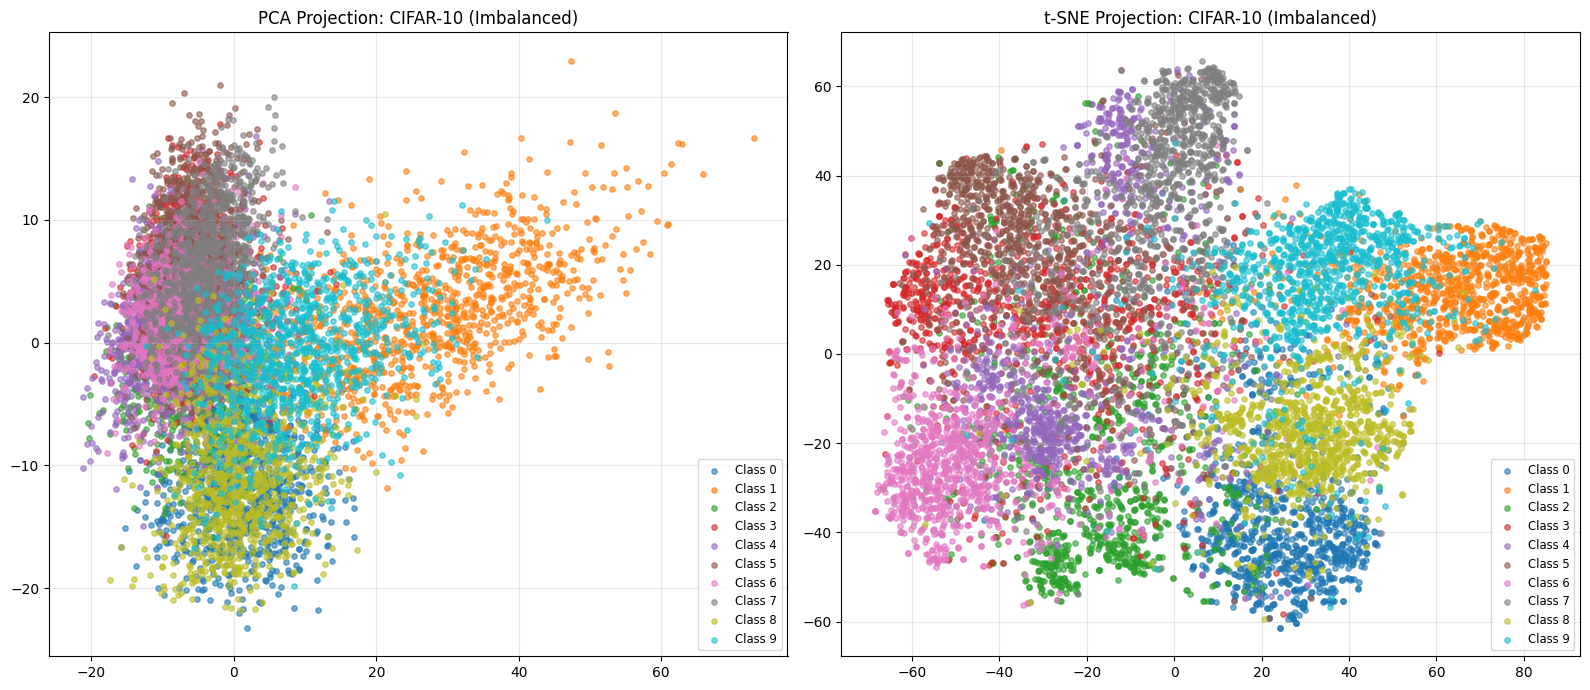

In [36]:
cifar_model = train_and_visualize(
    cifar_train,
    cifar_test,
    10,
    "CIFAR-10 (Imbalanced)",
    "Cross-Entropy (Baseline)"
)

The PCA Plot is a bit of a mess, trying to reduce dimensionality into 2 can cause this. Though we can see some clusters.

The t-SNE Projection shows a better picture, we can see distinct regions, though there are still messy and overlapping areas.

Training Model for Skin Cancer MNIST (Imbalanced) Feature Extraction...
Epoch 1 Loss: 1.2147
Epoch 2 Loss: 1.0464
Epoch 3 Loss: 1.1080
Epoch 4 Loss: 1.1055
Epoch 5 Loss: 1.1427
Epoch 6 Loss: 0.9790
Epoch 7 Loss: 0.9582
Epoch 8 Loss: 0.9280
Epoch 9 Loss: 0.8886
Epoch 10 Loss: 0.8367
Epoch 11 Loss: 0.7952
Epoch 12 Loss: 0.7423
Epoch 13 Loss: 0.6700
Epoch 14 Loss: 0.6120
Epoch 15 Loss: 0.5893
Computing PCA and t-SNE for Skin Cancer MNIST (Imbalanced)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipython-input-903775163.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab10', len(unique_classes))


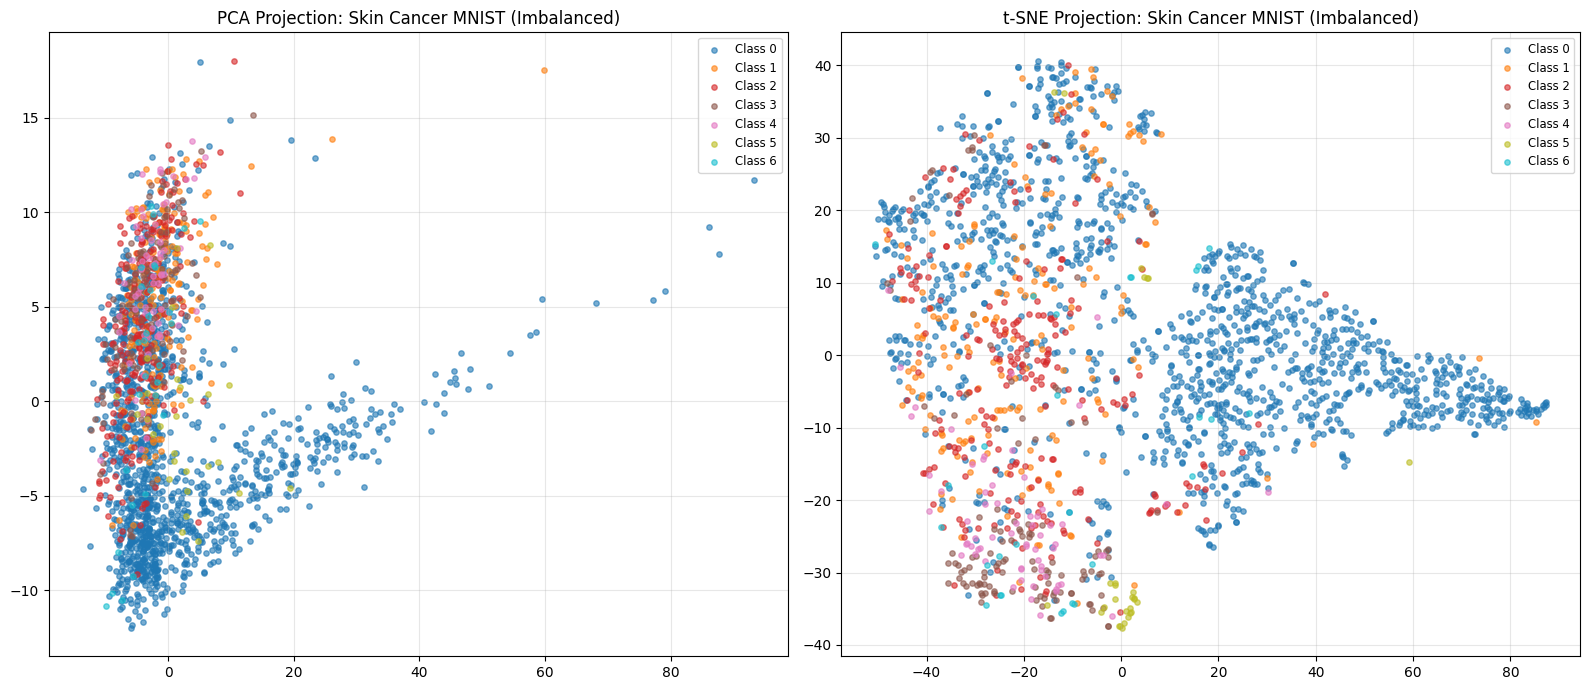

In [37]:
skin_model = train_and_visualize(
        skin_train,
        skin_test,
        7,
        "Skin Cancer MNIST (Imbalanced)",
        "Label Smoothing Cross-Entropy"
    )

The t-SNE plot shows a massive region filled with class 0 on one side and a diverse region filled with a bunch of other classes on the other.

Medical Images look very similar to each other.

## Problem Statement 6: Generalization & Transferability Test

In [32]:
def prepare_flowers_dataset():
    transform = get_standard_transforms()

    train_set = datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
    test_set = datasets.Flowers102(root='./data', split='test', download=True, transform=transform)

    return train_set, test_set

In [33]:
def find_target_directory(base_path, target_folder_name):
    for root, directories, files in os.walk(base_path):
        if target_folder_name in directories:
            return os.path.join(root, target_folder_name)
    return None

In [34]:
def prepare_blood_cells_dataset(data_folder):
    train_directory = find_target_directory(data_folder, "TRAIN")
    test_directory = find_target_directory(data_folder, "TEST")

    transform = get_standard_transforms()

    train_set = datasets.ImageFolder(root=train_directory, transform=transform)
    test_set = datasets.ImageFolder(root=test_directory, transform=transform)

    return train_set, test_set

In [35]:
def build_transfer_learning_model(base_model, num_target_classes, freeze_feature_extractor):
    transfer_model = copy.deepcopy(base_model)

    if freeze_feature_extractor:
        for parameter in transfer_model.parameters():
            parameter.requires_grad = False

    if hasattr(transfer_model, 'classifier') and isinstance(transfer_model.classifier, nn.Sequential):
        in_features = transfer_model.classifier[2].in_features
        transfer_model.classifier[2] = nn.Linear(in_features, num_target_classes)

    elif hasattr(transfer_model, 'fc'):
        in_features = transfer_model.fc.in_features
        transfer_model.fc = nn.Linear(in_features, num_target_classes)

    return transfer_model.to(device)

In [43]:
def execute_domain_transfer_experiment(base_model, train_set, test_set, num_classes, loss_function_name, experiment_title):
    print(f"\n--- Strategy A: Feature Extraction ({experiment_title}) ---")

    feature_extractor_model = build_transfer_learning_model(base_model, num_classes, freeze_feature_extractor=True)

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

    criterion = get_loss_criterion(loss_function_name, train_set, num_classes)

    optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, feature_extractor_model.parameters()), lr=0.001)
    scheduler_fe = optim.lr_scheduler.OneCycleLR(optimizer_fe, max_lr=0.01, epochs=20, steps_per_epoch=len(train_loader))

    train_network(feature_extractor_model, train_loader, criterion, optimizer_fe, scheduler_fe, epochs=20)
    evaluate_network(feature_extractor_model, test_loader, f"{experiment_title} (Feature Extraction)")

    print(f"\n--- Strategy B: Fine-Tuning ({experiment_title}) ---")

    fine_tuning_model = build_transfer_learning_model(base_model, num_classes, freeze_feature_extractor=False)

    optimizer_ft = optim.Adam(fine_tuning_model.parameters(), lr=0.0001)
    scheduler_ft = optim.lr_scheduler.OneCycleLR(optimizer_ft, max_lr=0.001, epochs=20, steps_per_epoch=len(train_loader))

    train_network(fine_tuning_model, train_loader, criterion, optimizer_ft, scheduler_ft, epochs=20)
    evaluate_network(fine_tuning_model, test_loader, f"{experiment_title} (Fine-Tuning)")

In [44]:
print("Preparing Oxford-102 Flowers Dataset...")
flowers_train, flowers_test = prepare_flowers_dataset()
execute_domain_transfer_experiment(
    cifar_model,
    flowers_train,
    flowers_test,
    102,
    "Cross-Entropy (Baseline)",
    "CIFAR-10 Model -> Flowers"
)

Preparing Oxford-102 Flowers Dataset...

--- Strategy A: Feature Extraction (CIFAR-10 Model -> Flowers) ---
Epoch 1 Loss: 5.1533
Epoch 2 Loss: 4.9535
Epoch 3 Loss: 4.6432
Epoch 4 Loss: 4.5280
Epoch 5 Loss: 5.1344
Epoch 6 Loss: 7.5510
Epoch 7 Loss: 9.5474
Epoch 8 Loss: 7.8377
Epoch 9 Loss: 6.2452
Epoch 10 Loss: 4.1315
Epoch 11 Loss: 2.8702
Epoch 12 Loss: 2.0025
Epoch 13 Loss: 1.4496
Epoch 14 Loss: 1.1514
Epoch 15 Loss: 0.9700
Epoch 16 Loss: 0.8410
Epoch 17 Loss: 0.7795
Epoch 18 Loss: 0.7459
Epoch 19 Loss: 0.7291
Epoch 20 Loss: 0.7169

Report for CIFAR-10 Model -> Flowers (Feature Extraction)
              precision    recall  f1-score   support

           0     0.1014    0.3500    0.1573        20
           1     0.7931    0.5750    0.6667        40
           2     0.0000    0.0000    0.0000        20
           3     0.1364    0.2500    0.1765        36
           4     0.1400    0.1556    0.1474        45
           5     0.0476    0.1200    0.0682        25
           6     0.2553

Feature Extraction achieved an accuracy of 27% while Fine-tuning achieved an accuracy of 33%.

Even though this accuracy is pretty low, transferring from a dataset of 10 classes to 102 classes with higher internal complexity is inherently difficult. But still, 33% is better than random guessing for a dataset of 102 classes.

In [46]:
print("Downloading and Preparing Blood Cells Dataset...")
blood_cells_directory = "blood_cells_data"
download_dataset_from_kaggle("paultimothymooney/blood-cells", blood_cells_directory)

blood_train, blood_test = prepare_blood_cells_dataset(blood_cells_directory)
execute_domain_transfer_experiment(
    skin_model,
    blood_train,
    blood_test,
    4,
    "Label Smoothing Cross-Entropy",
    "Skin Cancer Model -> Blood Cells"
)

Unzipping files...
Download and extraction complete.

--- Strategy A: Feature Extraction (Skin Cancer Model -> Blood Cells) ---
Epoch 1 Loss: 1.3654
Epoch 2 Loss: 1.2013
Epoch 3 Loss: 1.1440
Epoch 4 Loss: 1.1144
Epoch 5 Loss: 1.2482
Epoch 6 Loss: 1.4508
Epoch 7 Loss: 1.0717
Epoch 8 Loss: 1.0493
Epoch 9 Loss: 0.9607
Epoch 10 Loss: 0.9160
Epoch 11 Loss: 0.9363
Epoch 12 Loss: 0.8822
Epoch 13 Loss: 0.8371
Epoch 14 Loss: 0.8356
Epoch 15 Loss: 0.8248
Epoch 16 Loss: 0.8018
Epoch 17 Loss: 0.7923
Epoch 18 Loss: 0.7960
Epoch 19 Loss: 0.7876
Epoch 20 Loss: 0.7856

Report for Skin Cancer Model -> Blood Cells (Feature Extraction)
              precision    recall  f1-score   support

           0     0.5260    0.4880    0.5062       623
           1     0.8356    0.8032    0.8191       620
           2     0.8231    0.7355    0.7768       620
           3     0.3834    0.4663    0.4208       624

    accuracy                         0.6228      2487
   macro avg     0.6420    0.6233    0.6307      

Transferring from Skin Cancer to Blood Cells yielded a feature extraction result of 62% and a fine-tuning result of 80%.

##Error Analysis and Improvement Proposals

In [30]:
def compute_confusion_matrix(model, data_loader, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    model.eval()

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            for true_label, predicted_label in zip(labels.cpu().numpy(), predictions.cpu().numpy()):
                matrix[true_label][predicted_label] += 1

    return matrix

In [31]:
def display_confusion_matrix(matrix, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.title(title)
    plt.show()

In [32]:
def display_misclassified_images(model, data_loader, num_images):
    model.eval()
    misclassified_count = 0
    plt.figure(figsize=(15, 5))

    with torch.no_grad():
        for images, labels in data_loader:
            images_device = images.to(device)
            outputs = model(images_device)
            _, predictions = torch.max(outputs, 1)

            for index in range(len(labels)):
                true_label = labels[index].item()
                predicted_label = predictions[index].item()

                if true_label != predicted_label:
                    image_np = images[index].cpu().numpy().transpose((1, 2, 0))
                    image_np = np.clip((image_np * 0.5) + 0.5, 0, 1)

                    ax = plt.subplot(1, num_images, misclassified_count + 1)
                    ax.imshow(image_np)
                    ax.set_title(f"True: {true_label} | Pred: {predicted_label}")
                    ax.axis('off')

                    misclassified_count += 1
                    if misclassified_count >= num_images:
                        plt.tight_layout()
                        plt.show()
                        return

In [33]:
def perform_error_analysis(model, test_dataset, num_classes, dataset_name):
    print(f"Executing Error Analysis for {dataset_name}...")

    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    conf_matrix = compute_confusion_matrix(model, test_loader, num_classes)
    display_confusion_matrix(conf_matrix, f"Confusion Matrix: {dataset_name}")

    print("Displaying sample misclassifications...")
    display_misclassified_images(model, test_loader, 5)

Executing Error Analysis for CIFAR-10...


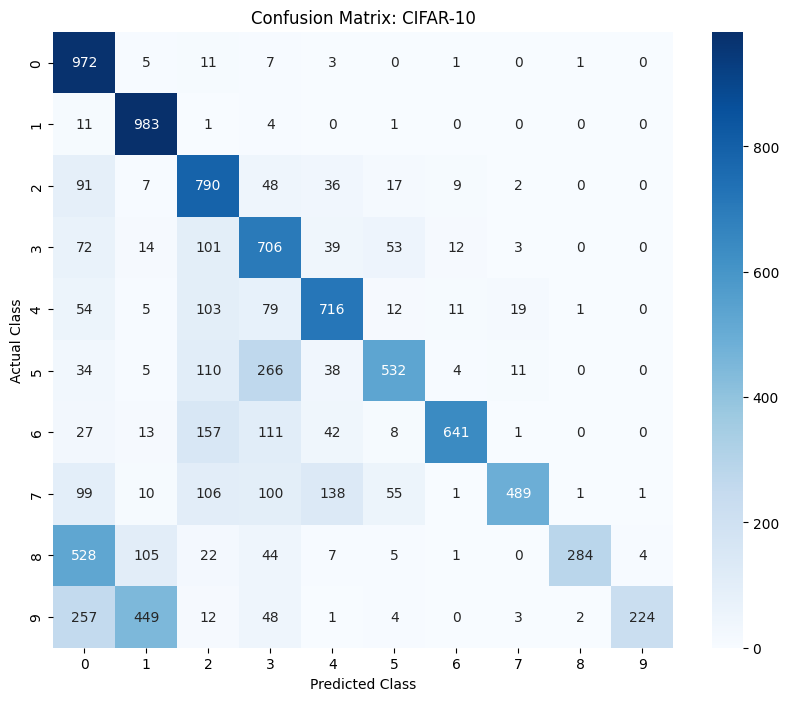

Displaying sample misclassifications...


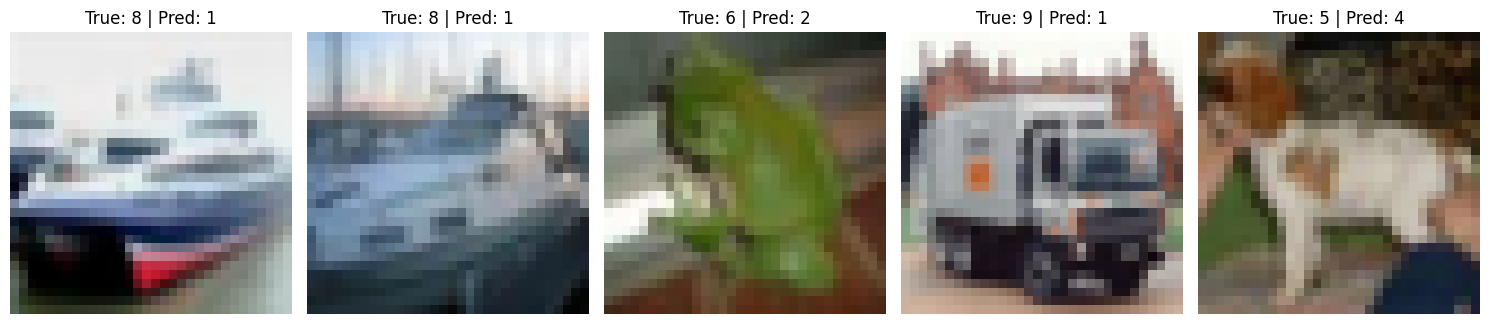

Executing Error Analysis for Skin Cancer MNIST...


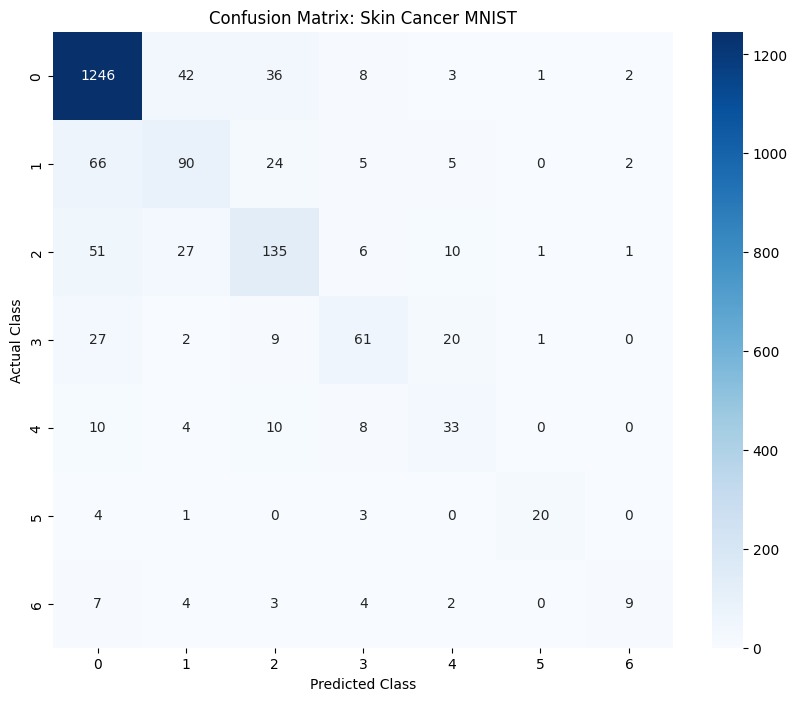

Displaying sample misclassifications...


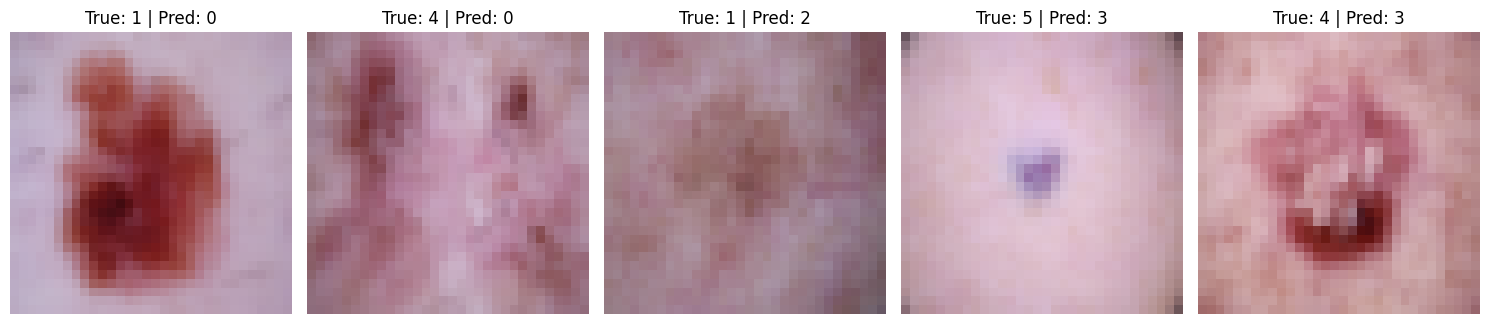

In [39]:
perform_error_analysis(cifar_model, cifar_test, 10, "CIFAR-10")

if skin_train:
    perform_error_analysis(skin_model, skin_test, 7, "Skin Cancer MNIST")

**CIFAR-10**

The model largely predicts accurately though for the most minority classes, it messes up. it often misclassifies trucks (class 9) to automobiles (class 1) and ships (class 8) to airplanes (class 0).

**Skin Cancer MNIST**

The model is extremely accurate for Class 0. While for the rest of the classes it does predict accurately a plurality of the times but it has an extremely high error, especially for the extremely rare Class 6.

**Proposals for Improvement:**


*   Hard-Negative Mining: Instead of blindly oversampling, we should look for specific items that look like examples of another class (example trucks that look like a car) and force the model to heavily train on them
*   Augmentations: Will force the model to look at textural features instead of just memorizing the images.
*   Multi-Resolution Cropping: For the medical dataset, resizing to 32x32 is not viable as the model needs to see the subtle variations. We can implement a 2-stream architecture, one takes the downscaled image, the other takes a high-res center crop.
*   Spatial Attention Layer: would force the model to look at the lesion's border irregularities rather than the surrounding healthy skin.

